<a href="https://colab.research.google.com/github/dsb4k8/data-science-utils-exploration/blob/main/breast_cancer_analysys.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preprocessing

Pulling `sklearn.datasets` Wisconsin Breast Cancer dataset

In [16]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load the pre-packaged dataset into df
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

# Checking
df


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


One way to classify / predict breast cancer in patients is by running a **logistic regression** of the target outcome `1` or `0` against features which correlate highly with the outcome - i.e how a `cloud_coverage_percentage` feature might be a good feature if one wanted to predict if past weather data resulted in rain

You might be asking though, **how do we find the most relavant features when it isnt super obvious?** (possible combinations, continuous values, etc)?

We can use a **Correlation Matrix**
- compute correlations across all features (raged [-1.0, 1.0]), against the target column
- convert to absolute values to group both strong positive AND strong negative relationships
- sort them from strongest association to weakest


In [14]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Load dataset into Pandas
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['Target'] = cancer_data.target

correlations = df.corr()['Target'].drop('Target')
strongest_features = correlations.abs().sort_values(ascending=False)

print("Top 5 most correlated features:")
print(df[strongest_features.index[:5]].corrwith(df['Target']))


Top 5 most correlated features:
worst concave points   -0.793566
worst perimeter        -0.782914
mean concave points    -0.776614
worst radius           -0.776454
mean perimeter         -0.742636
dtype: float64


### Visualizing the correlations

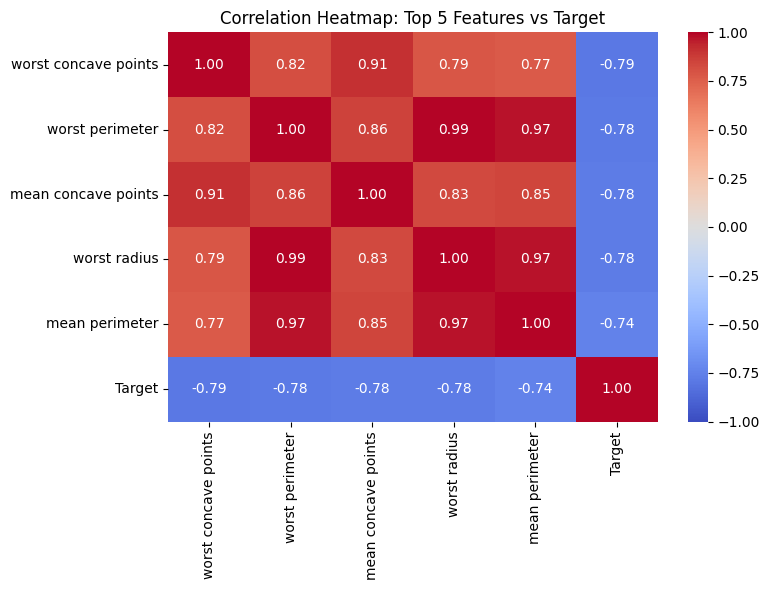

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the dataframe to only include the top 5 features and the target
top_5_features = strongest_features.index[:5].tolist()
heatmap_data = df[top_5_features + ['Target']]

# 2. Calculate the full correlation matrix for these variables
corr_matrix = heatmap_data.corr()

# 3. Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,          # Show the correlation numbers
    cmap='coolwarm',     # Red for positive, blue for negative correlation
    fmt=".2f",           # Round to 2 decimal places
    vmin=-1, vmax=1      # Set absolute bounds for correlation scale
)
plt.title("Correlation Heatmap: Top 5 Features vs Target")
plt.tight_layout()
plt.show()


As we can see above, there is a strong negative correlation across these features against the target on the bottom row and right column.

There is also however high "multicoliniarity" (inter-feature correlation) in nearly all other columns. this means there is alot of shared data between these features - i.e worst perimeter and worst radius are nearly 99% identical...

If we pass these all in as a set to our logistic regression model, it will assign wildly variable weights because it will not know which feature in particular is influencing the target.

To address this, we can drop the redundant features before training the model

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Select non-redundant features based on the heatmap
# i.e
# keeping 'worst concave points' (highest correlation to target)
# picking 'worst radius' and drop 'worst perimeter' / 'mean perimeter' (redundant)
selected_features = ['worst concave points', 'worst radius', 'mean concave points']

X = df[selected_features]
y = df['Target']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (CRITICAL for stable Logistic Regression weights)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Logistic Regression Classifier
lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

# Evaluate the model
y_pred = lr_model.predict(X_test_scaled)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 6. Look at the weights (Coefficients)
for feature, weight in zip(selected_features, lr_model.coef_[0]):
    print(f"{feature} Weight: {weight:.4f}")


Model Accuracy: 97.37%

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

worst concave points Weight: -1.8766
worst radius Weight: -2.9013
mean concave points Weight: -0.9830
